## **PCA (Principal Component Analysis)**

Considere um conjunto de dados:

$$
\mathcal{D} = \{\mathbf{x}_i\}_{i=1}^{N}
\quad \text{onde} \quad \mathbf{x}_i \in \mathbb{R}^{D}
$$

Vamos encontrar uma projeção linear dos dados em um subespaço de dimensão $M < D$ tal que a variância das projeções seja máxima.

### **Projeção Unidimensional**

Inicialmente, considere a projeção dos dados em um subespaço unidimensional ($M = 1$). Posteriormente, o resultado será generalizado.

Seja $\boldsymbol{\omega}_1 \in \mathbb{R}^{D}$ um vetor unitário que define a direção de projeção. A projeção de cada vetor $\mathbf{x}_i$ nessa direção resulta em um escalar:

$$
z_i = \boldsymbol{\omega}_1^{\top}\mathbf{x}_i
$$

#### **Médias Empírica**

A média das projeções é dada por $\boldsymbol{\omega}_1^{\top}\bar{\mathbf{x}}$, onde $\bar{\mathbf{x}}$ representa a média empírica do conjunto de dados, definida por:

$$
\bar{\mathbf{x}} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{x}_i
$$

#### **Centralização**

Antes de aplicar o PCA, é necessário centralizar o conjunto de dados. A centralização é realizada pela transformação:

$$
\mathbf{x}_i \leftarrow \mathbf{x}_i - \bar{\mathbf{x}}, \quad i = 1, \dots, N
$$

#### **Variância das Projeções e Matriz de Covariância**

A variância das projeções é dada por:

$$
\frac{1}{N}\sum_{i=1}^{N}\left(\boldsymbol{\omega}_1^{\top}\mathbf{x}_i - \boldsymbol{\omega}_1^{\top}\bar{\mathbf{x}}\right)^2
$$

Essa expressão pode ser escrita de forma matricial como:

$$
\boldsymbol{\omega}_1^{\top} \mathbf{S} \boldsymbol{\omega}_1
$$

onde $\mathbf{S} \in \mathbb{R}^{D \times D}$ é a matriz de covariância do conjunto de dados, definida por:

$$
\mathbf{S} = \frac{1}{N}\sum_{i=1}^{N}(\mathbf{x}_i - \bar{\mathbf{x}})(\mathbf{x}_i - \bar{\mathbf{x}})^{\top}
$$

A matriz $\mathbf{S}$ também pode ser expressa na forma matricial como:

$$
\mathbf{S} = \frac{1}{N} \mathbf{X}^{\top} \mathbf{X}
$$

onde $\mathbf{X} \in \mathbb{R}^{N \times D}$ é a matriz de dados centrados, cujas linhas são os vetores $\mathbf{x}_i^{\top}$.

#### **Otimização via Multiplicadores de Lagrange**

Desejamos maximizar $\boldsymbol{\omega}_1^{\top} \mathbf{S} \boldsymbol{\omega}_1$ com respeito a $\boldsymbol{\omega}_1$, sujeito à restrição $\boldsymbol{\omega}_1^{\top}\boldsymbol{\omega}_1 = 1$.

Para isso, introduzimos um multiplicador de Lagrange $\lambda_1$ e definimos a seguinte função Lagrangiana:

$$
\mathcal{L}(\boldsymbol{\omega}_1, \lambda_1) = \boldsymbol{\omega}_1^{\top} \mathbf{S} \boldsymbol{\omega}_1 - \lambda_1(\boldsymbol{\omega}_1^{\top}\boldsymbol{\omega}_1 - 1)
$$

Impondo a condição de otimalidade $\dfrac{\partial \mathcal{L}}{\partial \boldsymbol{\omega}_1} = 0$, obtemos:

$$
\mathbf{S} \boldsymbol{\omega}_1 = \lambda_1 \boldsymbol{\omega}_1
$$

Portanto, $\boldsymbol{\omega}_1$ é um autovetor da matriz $\mathbf{S}$. Multiplicando ambos os lados da equação por $\boldsymbol{\omega}_1^{\top}$, segue que:

$$
\boldsymbol{\omega}_1^{\top} \mathbf{S} \boldsymbol{\omega}_1 = \lambda_1 \boldsymbol{\omega}_1^{\top}\boldsymbol{\omega}_1
$$

Como $\boldsymbol{\omega}_1^{\top}\boldsymbol{\omega}_1 = 1$, temos:

$$
\lambda_1 = \boldsymbol{\omega}_1^{\top} \mathbf{S} \boldsymbol{\omega}_1
$$

Assim, o vetor $\boldsymbol{\omega}_1$ ótimo corresponde ao autovetor associado ao maior autovalor de $\mathbf{S}$, denotado por $\lambda_1$.

#### **Generalização para $M$ dimensões**

Para um subespaço $M$-dimensional, buscamos determinar os $M$ maiores **autovalores** de $\mathbf{S}$ e os **autovetores** correspondentes.

A projeção de um vetor de dados $\mathbf{x}_i$ nesse subespaço é dada por:

$$
\mathbf{z}_i = \mathbf{W}^{\top}\mathbf{x}_i
$$

onde $\mathbf{W} \in \mathbb{R}^{D \times M}$ é a matriz formada pelos $M$ autovetores associados aos maiores autovalores de $\mathbf{S}$:

$$
\mathbf{W} = [\boldsymbol{\omega}_1,\ \boldsymbol{\omega}_2,\ \dots,\ \boldsymbol{\omega}_M]
$$

> BISHOP, Christopher M. Pattern Recognition and Machine Learning. New York: Springer, 2006. Seção 12.1.1, p. 561.

## **Exemplo Prático**

Queremos, dado um conjunto $D$ dimensional, reduzir a dimensionalidade para $M = 1$ e $M = 2$.

In [50]:
from sklearn.datasets import make_classification

X_raw, _ = make_classification(
    n_samples=200,
    n_features=3,
    n_informative=2,
    n_redundant=1,
    n_clusters_per_class=1,
    random_state=42
)

X = X_raw

N, D = X.shape
print("Número de amostras:", N)
print("Dimensão dos dados:", D)

Número de amostras: 200
Dimensão dos dados: 3


### **Vizualização dos dados**

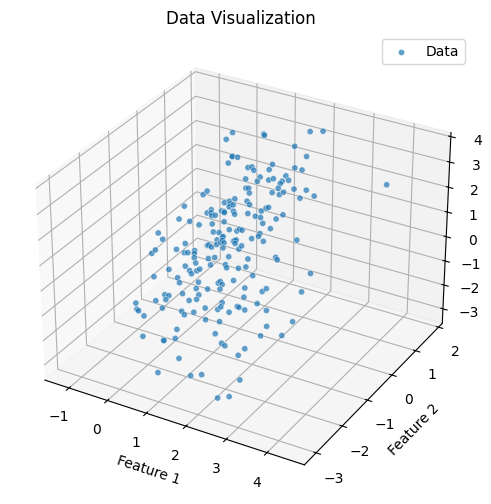

In [51]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

ax.scatter(X[:, 0], X[:, 1], X[:, 2], edgecolors="white", linewidths=0.4, alpha=0.7, label="Data")

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")
ax.set_title("Data Visualization")
ax.legend()

plt.show()

### **Centralização da Média**

In [52]:
import numpy as np

mu = np.mean(X, axis=0)

print("Média antes da centralização:", mu)

X_centered = X - mu

print("Média após centralização:", np.mean(X_centered, axis=0))

Média antes da centralização: [ 0.99804798 -0.41530353  0.12729097]
Média após centralização: [-4.35207426e-16  7.88258347e-17  8.21565038e-17]


### **Matriz de Convariância**

In [53]:
S = (1/N) * X_centered.T @ X_centered

print("Matriz de covariância S:")
print(S)

Matriz de covariância S:
[[ 1.05415552 -0.29121521  0.34528154]
 [-0.29121521  1.04577585  1.28504277]
 [ 0.34528154  1.28504277  2.08712389]]


### **Cálculo dos Autovalores e Autovetores**

In [54]:
eigenvalues, eigenvectors = np.linalg.eigh(S)

print("Autovalores:")
print(eigenvalues)

print("\nAutovetores:")
print(eigenvectors)


Autovalores:
[-3.26128013e-16  1.22577698e+00  2.96127827e+00]

Autovetores:
[[ 0.38259241  0.92148052  0.06705747]
 [ 0.75715325 -0.35430232  0.54880672]
 [-0.52947332  0.15919651  0.83325535]]


In [55]:
idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Autovalores ordenados:")
print(eigenvalues)

Autovalores ordenados:
[ 2.96127827e+00  1.22577698e+00 -3.26128013e-16]


### **PCA para $M = 2$**

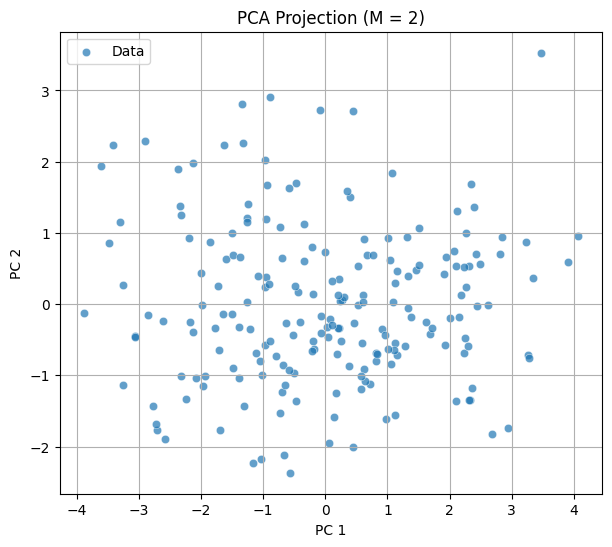

In [56]:
import matplotlib.pyplot as plt

M = 2
W2 = eigenvectors[:, :2]

Z2 = X_centered @ W2

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(Z2[:, 0], Z2[:, 1], edgecolors="white", linewidths=0.4, alpha=0.7, label="Data")

ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_title("PCA Projection (M = 2)")
ax.legend()
plt.grid(True)

plt.show()

### **PCA para $M = 1$**

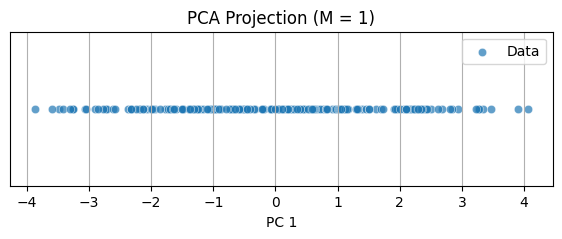

In [57]:
M = 1
W1 = eigenvectors[:, :M]

Z1 = X_centered @ W1

fig, ax = plt.subplots(figsize=(7, 2))

ax.scatter(Z1[:, 0], np.zeros_like(Z1[:, 0]), edgecolors="white", linewidths=0.4, alpha=0.7, label="Data")

ax.set_xlabel("PC 1")
ax.set_title("PCA Projection (M = 1)")
ax.set_yticks([])
ax.legend()
plt.grid(True)

plt.show()